In [1]:
# Install scikit-learn-extra
!pip install scikit-learn-extra

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids # This should work now
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from yellowbrick.cluster import SilhouetteVisualizer

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Actual labels (for visualization only)

In [3]:

# Convert to DataFrame for better analysis
df = pd.DataFrame(X, columns=iris.feature_names)

In [4]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Finding the Optimal Number of Clusters using Elbow Method
cost_values = []
K_range = range(2, 8)

for k in K_range:
    kmedoids = KMedoids(n_clusters=k, metric='manhattan', random_state=42)
    kmedoids.fit(X_scaled)
    cost_values.append(kmedoids.inertia_)

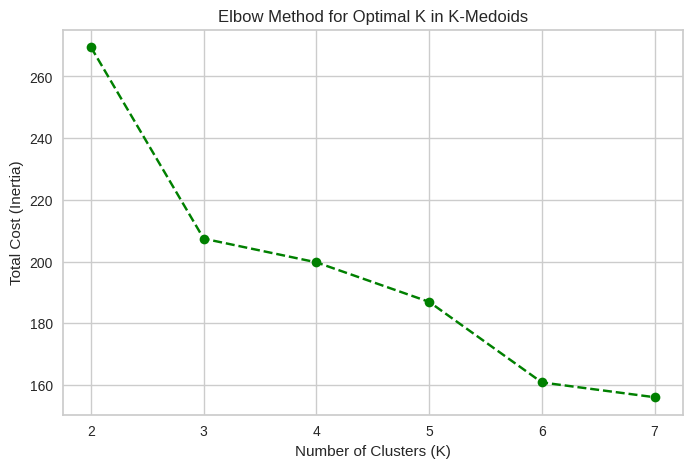

In [20]:
# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, cost_values, marker='o', linestyle='--', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Total Cost (Inertia)')
plt.title('Elbow Method for Optimal K in K-Medoids')
plt.show()

In [7]:
# Apply K-Medoids clustering with Manhattan distance (choosing K=3)
kmedoids = KMedoids(n_clusters=3, metric='manhattan', random_state=42)
clusters = kmedoids.fit_predict(X_scaled)

In [8]:
# Add cluster labels to DataFrame
df['Cluster'] = clusters

In [9]:
# Calculate total cost
total_cost = kmedoids.inertia_

In [10]:
# Silhouette Score - Evaluates clustering quality
sil_score = silhouette_score(X_scaled, clusters, metric='manhattan')

In [11]:
# Print analysis
print(f"Total Cost (Sum of distances to medoids): {total_cost}")
print(f"Silhouette Score: {sil_score:.4f}")

Total Cost (Sum of distances to medoids): 207.42262930588046
Silhouette Score: 0.4886


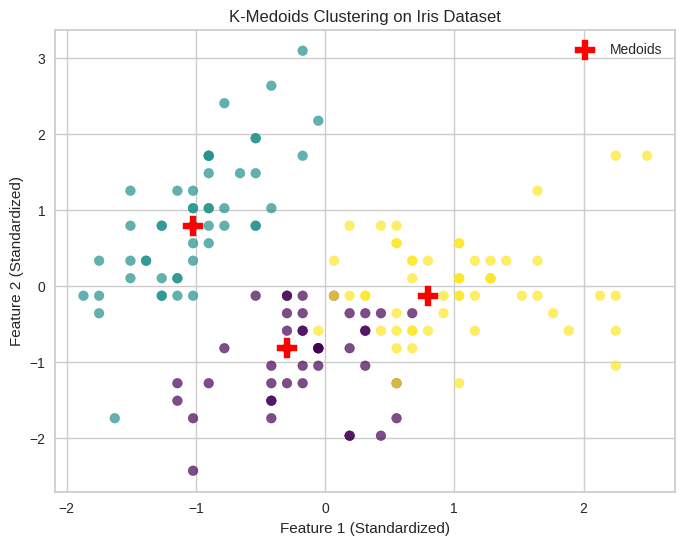

In [12]:
# Scatter Plot for Clusters
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.scatter(kmedoids.cluster_centers_[:, 0], kmedoids.cluster_centers_[:, 1],
            marker='P', s=200, c='red', label='Medoids')
plt.title('K-Medoids Clustering on Iris Dataset')
plt.legend()
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.show()

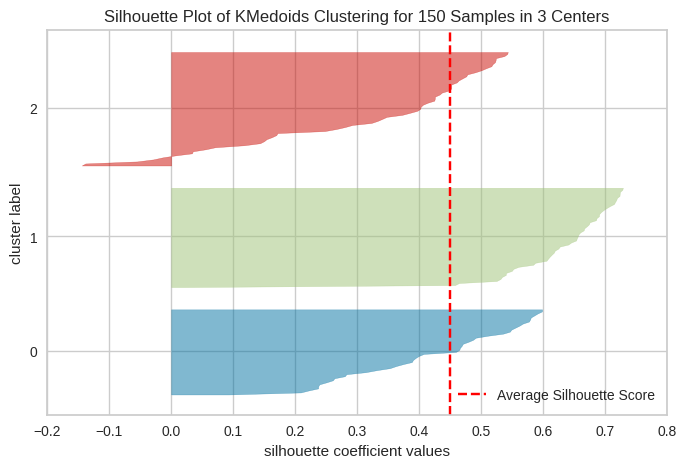

<Axes: title={'center': 'Silhouette Plot of KMedoids Clustering for 150 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [13]:
# Silhouette Analysis for Cluster Quality
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
visualizer = SilhouetteVisualizer(kmedoids, colors='yellowbrick', ax=ax)
visualizer.fit(X_scaled)
visualizer.show()

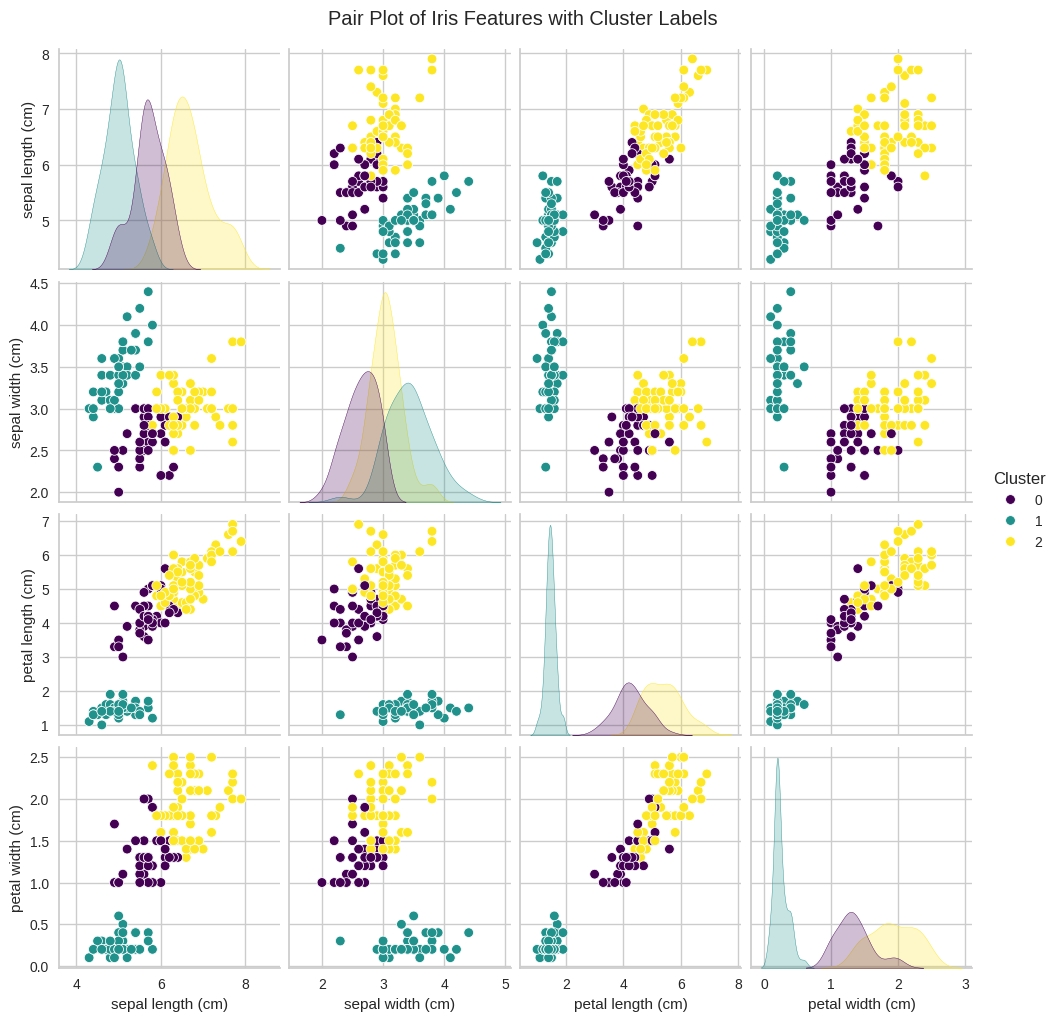

In [14]:
# Pair Plot for Feature Relationships Across Clusters
sns.pairplot(df, hue='Cluster', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot of Iris Features with Cluster Labels', y=1.02)
plt.show()

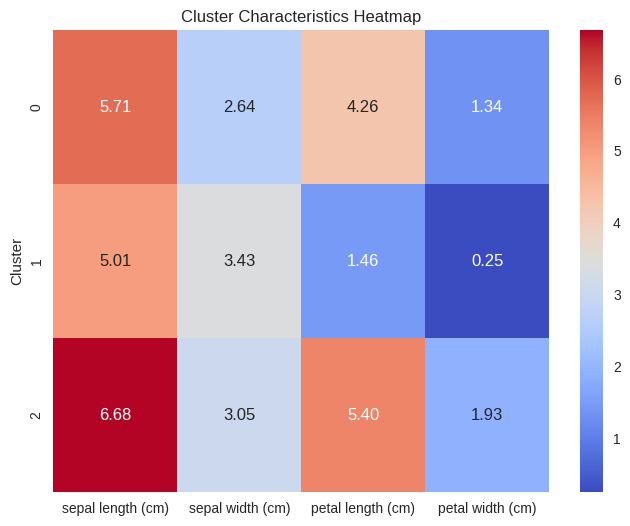

In [16]:
# Heatmap to Analyze Cluster Characteristics
cluster_means = df.groupby('Cluster').mean()
plt.figure(figsize=(8,6))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cluster Characteristics Heatmap")
plt.show()

# Cluster Characteristics Heatmap Analysis

## **Overview**
This heatmap represents the characteristics of different clusters based on four flower features:  
- **Sepal Length (cm)**  
- **Sepal Width (cm)**  
- **Petal Length (cm)**  
- **Petal Width (cm)**  

The values in the heatmap indicate the average measurements for each feature within a given cluster.

---

## **Cluster-wise Analysis**
### **Cluster 0**
- **Sepal Length:** 5.71 cm (Moderate)
- **Sepal Width:** 2.64 cm (Lowest)
- **Petal Length:** 4.26 cm (Moderate)
- **Petal Width:** 1.34 cm (Moderate)

Cluster 0 exhibits moderate sepal and petal characteristics, with the lowest **sepal width** among all clusters.

---

### **Cluster 1**
- **Sepal Length:** 5.01 cm (Lowest)
- **Sepal Width:** 3.43 cm (Highest)
- **Petal Length:** 1.46 cm (Lowest)
- **Petal Width:** 0.25 cm (Lowest)

Cluster 1 has the **smallest petals (both length and width)** and the **widest sepals**, suggesting that this cluster likely represents a distinct category of flowers with short petals.

---

### **Cluster 2**
- **Sepal Length:** 6.68 cm (Highest)
- **Sepal Width:** 3.05 cm (Moderate)
- **Petal Length:** 5.40 cm (Highest)
- **Petal Width:** 1.93 cm (Highest)

Cluster 2 has the **largest sepals and petals**, indicating that flowers in this cluster have significantly larger dimensions compared to the others.

---

## **Key Takeaways**
1. **Cluster 1** has the **smallest** petals and is likely a separate species from Clusters 0 and 2.
2. **Cluster 2** has the **largest** sepals and petals, suggesting it consists of flowers with large dimensions.
3. **Cluster 0** represents a middle-ground cluster with moderate values for most features.

This clustering may align with different species of flowers in datasets such as **Iris**, where clusters might correspond to **Setosa, Versicolor, and Virginica**.

---


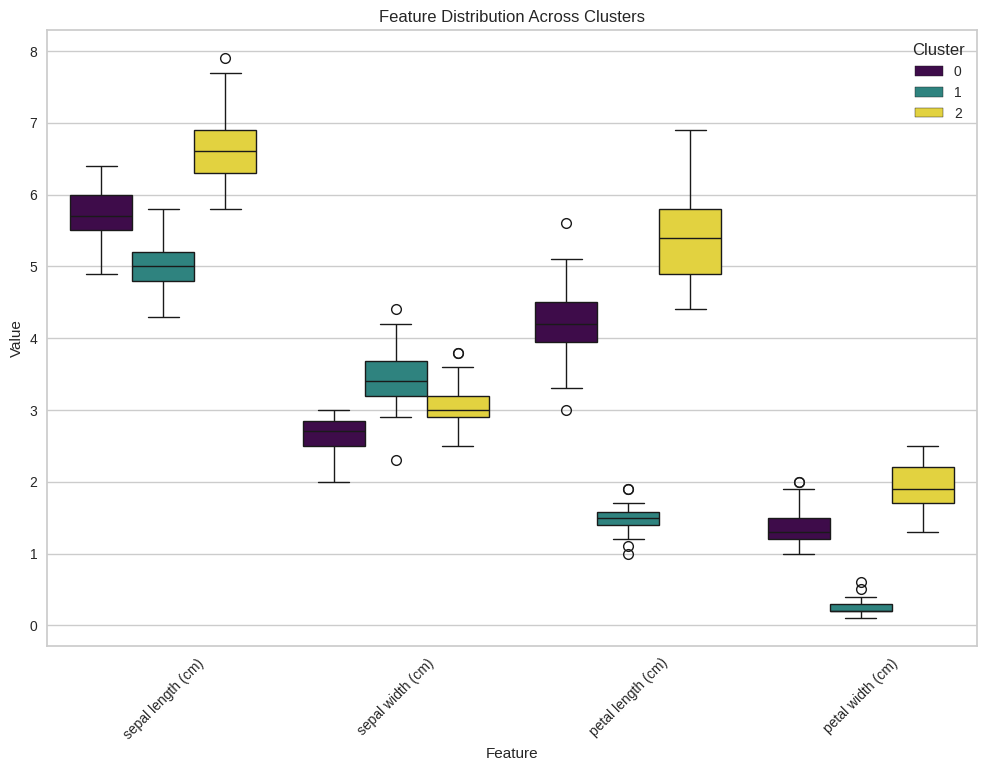

In [17]:
# Box Plot to Analyze Feature Distribution Across Clusters
plt.figure(figsize=(12, 8))
df_melted = df.melt(id_vars=["Cluster"], var_name="Feature", value_name="Value")
sns.boxplot(x="Feature", y="Value", hue="Cluster", data=df_melted, palette='viridis')
plt.xticks(rotation=45)
plt.title("Feature Distribution Across Clusters")
plt.show()

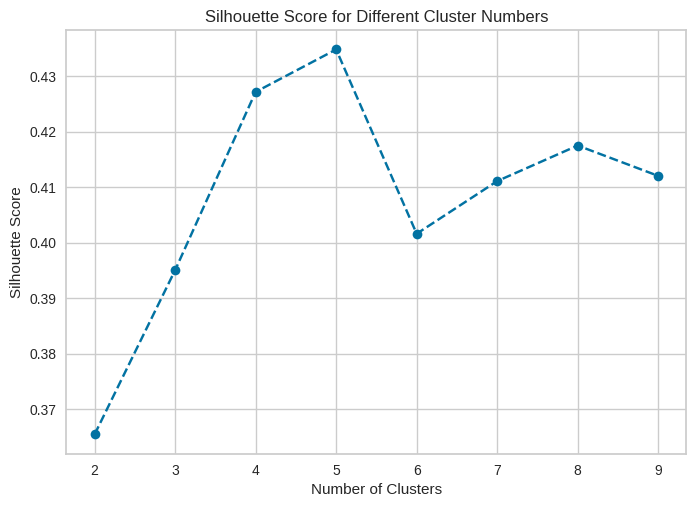

Optimal Number of Clusters: 5, Highest Silhouette Score: 0.43


In [22]:
from sklearn.metrics import silhouette_score

best_k = None
best_score = -1
silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    if score > best_score:
        best_score = score
        best_k = k

# Plot Silhouette Scores
plt.plot(range(2, 10), silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Cluster Numbers')
plt.show()

print(f'Optimal Number of Clusters: {best_k}, Highest Silhouette Score: {best_score:.2f}')
